# Odejścia klientów w branży telekomunikacyjnej

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/preprocessed_telco_customer_churn.csv", index_col=0)
df.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,online_security,online_backup,device_protection,...,internet_service_fiber_optic,internet_service_no,contract_month_to_month,contract_one_year,contract_two_year,payment_method_bank_transfer_automatic,payment_method_credit_card_automatic,payment_method_electronic_check,payment_method_mailed_check,churn
customerID,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,1,0,0
5575-GNVDE,1,0,0,0,34,1,0,1,0,1,...,0,0,0,1,0,0,0,0,1,0
3668-QPYBK,1,0,0,0,2,1,0,1,1,0,...,0,0,1,0,0,0,0,0,1,1
7795-CFOCW,1,0,0,0,45,0,0,1,0,1,...,0,0,0,1,0,1,0,0,0,0
9237-HQITU,0,0,0,0,2,1,0,0,0,0,...,1,0,1,0,0,0,0,1,0,1


#### Rozkład rezygnacji klientów

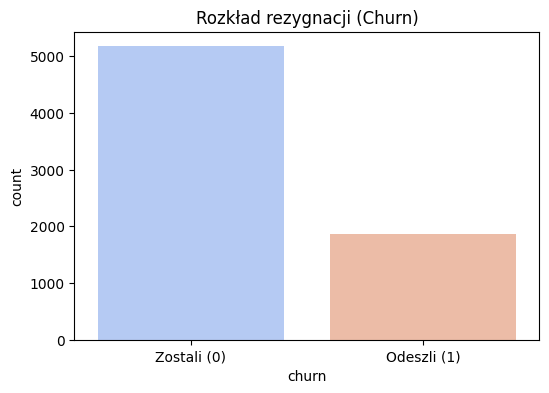

In [62]:
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df, hue='churn', palette='coolwarm', legend=False)
plt.title('Rozkład rezygnacji (Churn)')
plt.xticks([0, 1], ['Zostali (0)', 'Odeszli (1)'])
plt.show()

Wykres pokazuje, że większość klientów pozostaje w firmie, a grupa osób odchodzących (churn) stanowi wyraźną mniejszość, co jest typowym układem dla tego problemu biznesowego.

#### Korelacja cech ze zmienną **churn** (odejście klienta)

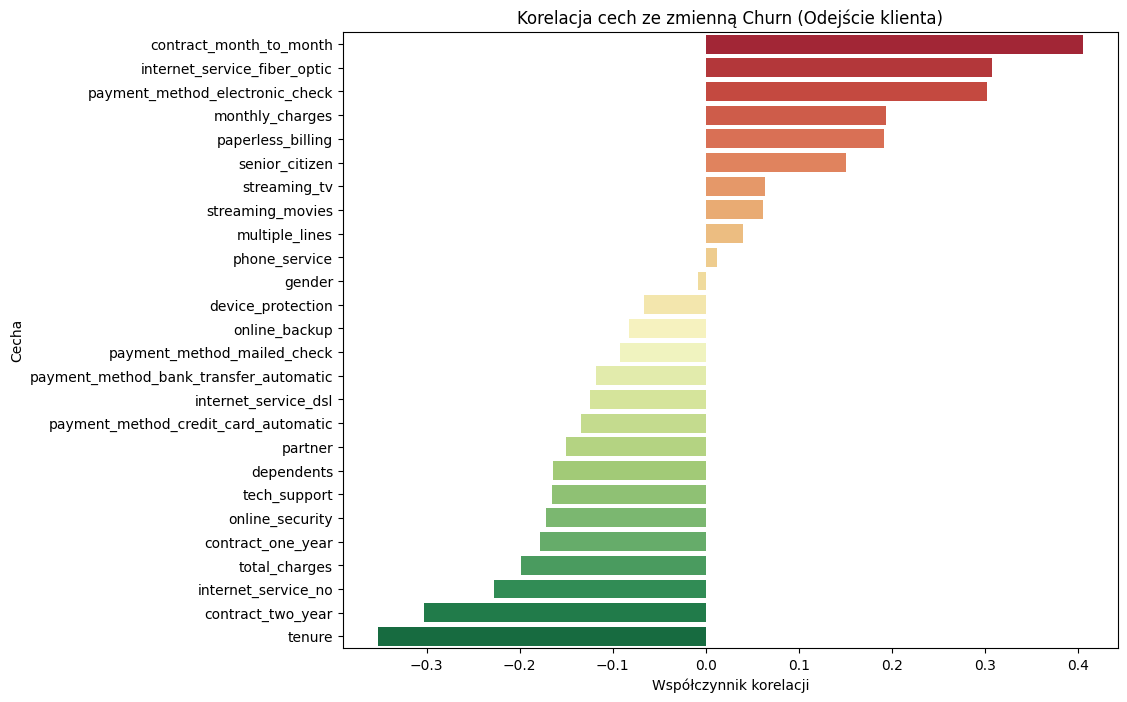

In [63]:
plt.figure(figsize=(10, 8))

churn_corr = df.corr()['churn'].drop('churn').sort_values(ascending=False)

sns.barplot(
    x=churn_corr.values, 
    y=churn_corr.index, 
    hue=churn_corr.index,
    palette='RdYlGn', 
    legend=False
)

plt.title('Korelacja cech ze zmienną Churn (Odejście klienta)')
plt.xlabel('Współczynnik korelacji')
plt.ylabel('Cecha')
plt.show()

Cechy na górze (kolor czerwony) mają dodatni związek z churn. Jeśli ta cecha występuje (wynosi 1), to prawdopodobieństwo odejścia klienta rośnie. Cechy na dole (kolor ciemnozielony) mają ujemny związek z churn. Jeśli ta cecha występuje (wynosi 1), tym mniejsza jest szansa na odejście klienta.

Wykres wskazuje, że najsilniejszymi czynnikami sprzyjającymi odejściu klienta są krótkoterminowe umowy (month-to-month) oraz korzystanie ze światłowodu i płatności czekiem elektronicznym. Z drugiej strony, długi staż pracy (tenure) oraz dwuletnie kontrakty najskuteczniej zatrzymują użytkowników w firmie. Cechy takie jak płeć czy posiadanie usługi telefonicznej mają znikomy wpływ na decyzję o rezygnacji.

#### Rozkład gęstości stażu klienta (tenure) względem rezygnacji

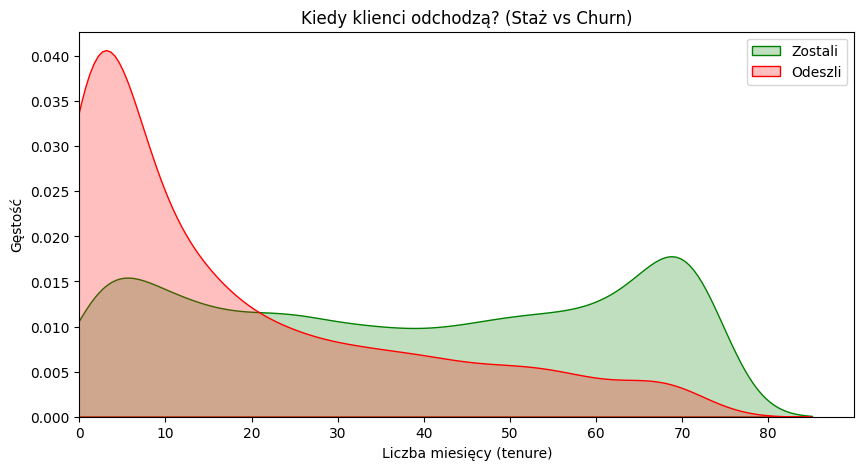

In [64]:
plt.figure(figsize=(10, 5))

sns.kdeplot(df[df['churn'] == 0]['tenure'], label='Zostali', fill=True, color='green')
sns.kdeplot(df[df['churn'] == 1]['tenure'], label='Odeszli', fill=True, color='red')

plt.title('Kiedy klienci odchodzą? (Staż vs Churn)')
plt.xlabel('Liczba miesięcy (tenure)')
plt.ylabel('Gęstość')
plt.xlim(0)
plt.ylim(0)
plt.legend()
plt.show()

Wykres gęstości ujawnia, że największe ryzyko odejścia występuje na samym początku relacji z klientem, o czym świadczy wyraźny czerwony szczyt w niskich wartościach stażu. Z kolei rozkład dla osób pozostających w firmie przesuwa się w stronę wysokich wartości, co potwierdza, że wraz z każdym kolejnym miesiącem prawdopodobieństwo, że klient zrezygnuje staje się coraz mniejsze.

#### Opłaty miesięczne a odejście

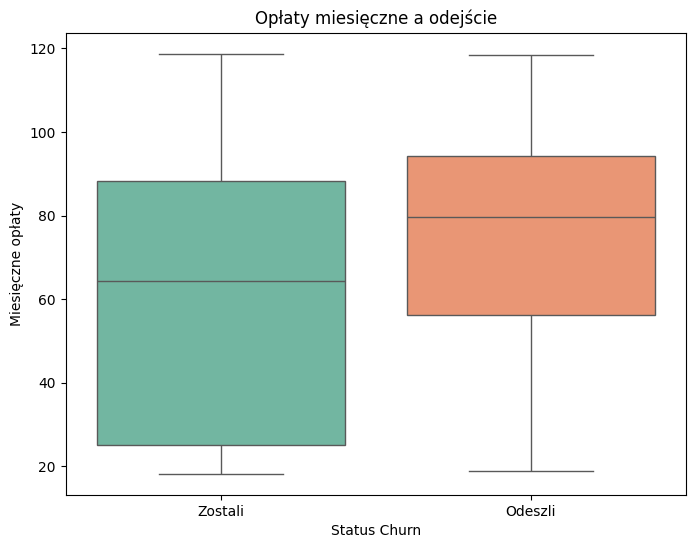

In [65]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='churn', y='monthly_charges', data=df, palette='Set2', hue='churn', legend=False)

plt.title('Opłaty miesięczne a odejście')
plt.xticks([0, 1], ['Zostali', 'Odeszli'])
plt.xlabel('Status Churn')
plt.ylabel('Miesięczne opłaty')
plt.show()

Pomarańczowe pole („Odeszli”) jest wyraźnie przesunięte w górę – mediana opłat wynosi tu ok. 80 jednostek, co oznacza, że rezygnują głównie klienci z droższymi pakietami.

Zielone pole („Zostali”) skupia się niżej, z medianą około 65 jednostek; pokazuje to, że tańsze usługi sprzyjają utrzymaniu klienta.

Widać wyraźnie, że wyższa cena usługi jest jednym z głównych czynników motywujących do rezygnacji.

## Machine learning

#### Podział zbioru na dane treningowe i testowe

In [66]:
from sklearn.model_selection import train_test_split

X = df.drop("churn", axis=1)
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=55, stratify=y)

print(X_train.shape)
print(X_test.shape)

(5634, 26)
(1409, 26)


### KNN (K-Nearest Neighbors)

In [67]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, RocCurveDisplay

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), ['tenure', 'monthly_charges', 'total_charges'])],
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier())
])


param_grid = {'knn__n_neighbors': range(1, 70)}
grid = GridSearchCV(pipeline, param_grid, cv=skf, scoring='f1')

grid.fit(X_train, y_train)

best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test)

print("--- KNN ---")
print(f"Best score for n_neighbors = {grid.best_params_['knn__n_neighbors']}")
print(f"Best F1 score: {grid.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nReport:")
print(classification_report(y_test, y_pred))

--- KNN ---
Best score for n_neighbors = 63
Best F1 score: 0.5891
Test accuracy: 0.8062

Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1035
           1       0.64      0.61      0.62       374

    accuracy                           0.81      1409
   macro avg       0.75      0.74      0.75      1409
weighted avg       0.80      0.81      0.80      1409



W analizie skuteczności modelu skupiono się na zdolności algorytmu do poprawnego rozróżnienia dwóch grup klientów: tych, którzy pozostają w firmie oraz tych, którzy rezygnują z usług.

#### 1. Klasa lojalna (0 – "Non-churn")
Model wykazuje bardzo wysoką stabilność w rozpoznawaniu klientów, którzy nie planują rezygnacji z usług:
- **Precision (0.86)**: Oznacza, że jeśli model przewiduje pozostanie klienta w firmie, ma rację w 86% przypadków.
- **Recall (0.88)**: Model poprawnie identyfikuje 88% wszystkich lojalnych klientów. Świadczy to o niskim ryzyku błędnego zakwalifikowania stabilnego klienta jako osoby „zagrożonej”.
- **F1-score (0.87)**: Wysoka średnia harmoniczna potwierdza, że model niemal bezbłędnie opisuje profil typowego, lojalnego klienta.

#### 2. Klasa zagrożona (1 – „Churn”)
W obszarze kluczowym z perspektywy biznesowej, wyniki modelu KNN wskazują na istotne ograniczenia:
- **Precision (0.64)**: Tylko 64% alarmów o odejściu klienta jest trafnych. Pozostałe 36% to „fałszywe alarmy”, które mogą generować niepotrzebne koszty akcji retencyjnych (np. oferowanie zniżek osobom, które i tak by zostały).
- **Recall (0.61)**: Jest to krytyczny parametr. Model wykrywa jedynie 61% faktycznych odejść. Oznacza to, że co drugi klient rezygnujący z usług pozostaje niewykryty przez algorytm, co uniemożliwia podjęcie działań zapobiegawczych.
- **F1-score (0.62)**: Wynik ten obrazuje niską efektywność modelu w balansowaniu między trafnością a czułością dla klasy Churn.


Model KNN, mimo wysokiej ogólnej dokładności (Test accuracy: 80.62%), charakteryzuje się niewystarczającą zdolnością predykcyjną w klasie mniejszościowej. Z perspektywy biznesowej, niski poziom Recall (0.61) jest nieakceptowalny, gdyż model pomija około 40% realnych odejść.

#### Macierz pomyłek i krzywa ROC

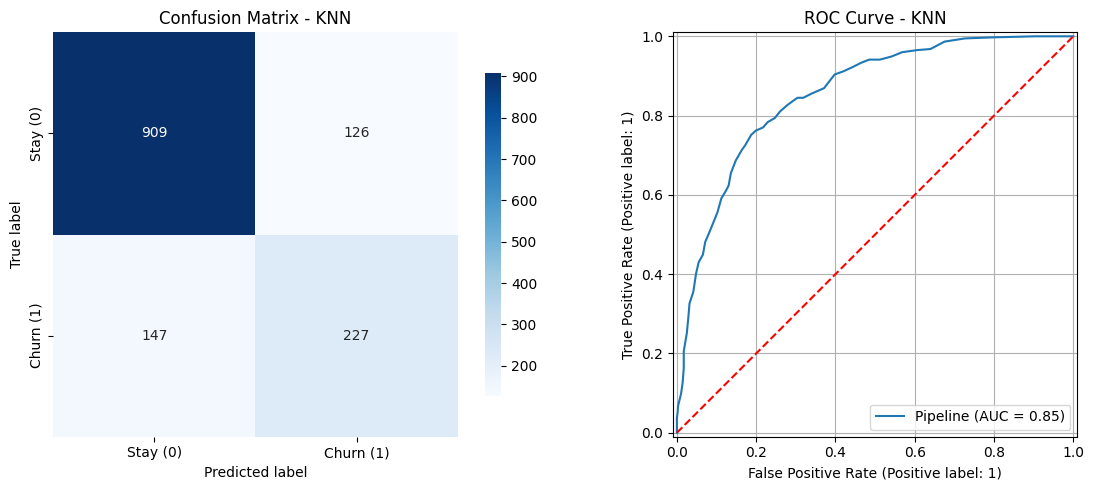

In [68]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True, cbar_kws={"shrink": .8},
            xticklabels=['Stay (0)', 'Churn (1)'], 
            yticklabels=['Stay (0)', 'Churn (1)'], ax=ax1)
ax1.set_xlabel('Predicted label')
ax1.set_ylabel('True label')
ax1.set_title('Confusion Matrix - KNN')

RocCurveDisplay.from_estimator(best_knn, X_test, y_test, ax=ax2)
ax2.plot([0, 1], [0, 1], color='red', linestyle='--')
ax2.set_title('ROC Curve - KNN')
ax2.set_aspect('equal')
ax2.grid(True)

plt.tight_layout()
plt.show()

Wykres macierzy pomyłek (Confusion Matrix) pokazuje, że model KNN poprawnie zidentyfikował 909 lojalnych klientów oraz 227 osób odchodzących, jednak błędnie zaklasyfikował 147 faktycznych odejść jako osoby zostające w firmie, co potwierdza jego niską skuteczność w wykrywaniu realnego zagrożenia rezygnacją (Churn).

Wykres krzywej ROC z wynikiem AUC na poziomie 0.85 potwierdza bardzo dobrą zdolność modelu KNN do rozróżniania klientów odchodzących od lojalnych, co wskazuje na jego wysoki potencjał analityczny mimo konieczności dopracowania czułości (Recall) w praktycznym zastosowaniu.

### Regresja logistyczna

In [69]:
from sklearn.linear_model import LogisticRegression

log_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('logreg', LogisticRegression())
])

param_grid_log = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logreg__class_weight': [None, 'balanced'],
    'logreg__solver': ['liblinear', 'lbfgs']
}

grid_log = GridSearchCV(log_pipeline, param_grid_log, cv=skf, scoring='f1')
grid_log.fit(X_train, y_train)

best_logreg = grid_log.best_estimator_
y_pred_log = best_logreg.predict(X_test)

print("--- Logistic Regression ---")
print(f"Best parameters: {grid_log.best_params_}")
print(f"Best F1 score (train): {grid_log.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_log):.4f}")

print("\nReport:")
print(classification_report(y_test, y_pred_log))

--- Logistic Regression ---
Best parameters: {'logreg__C': 0.1, 'logreg__class_weight': 'balanced', 'logreg__solver': 'lbfgs'}
Best F1 score (train): 0.6261
Test accuracy: 0.7608

Report:
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1035
           1       0.53      0.82      0.65       374

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



Model uzyskał najwyższą zdolność detekcji klasy pozytywnej (Recall: 0.82), co oznacza, że poprawnie zidentyfikował 82% wszystkich faktycznych przypadków odejścia klientów. Pomimo niższego wskaźnika Precision (0.53) skutkującego większą liczbą "fałszywych alarmów", model osiągnął najwyższą ogólną efektywność w balansowaniu tych metryk (F1-score: 0.65).

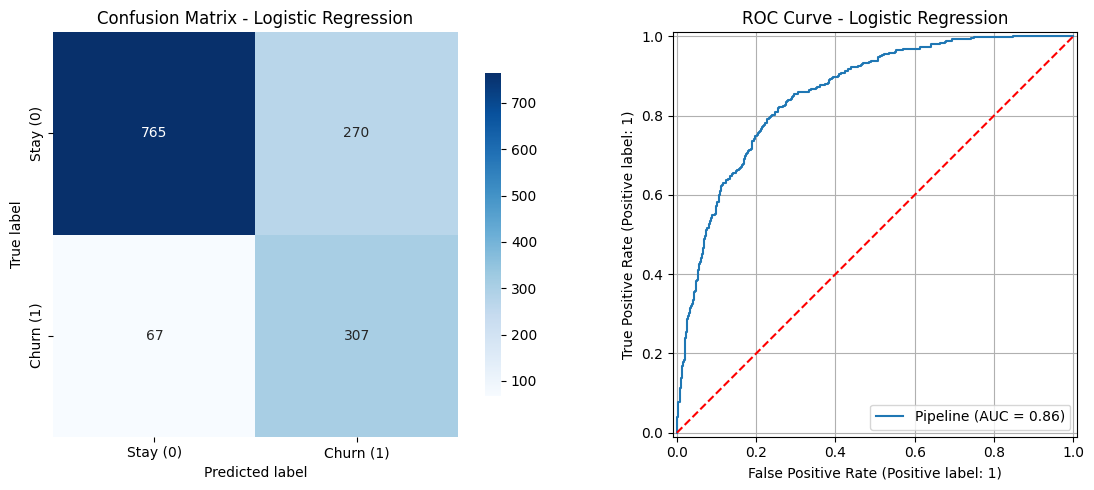

In [70]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True, cbar_kws={"shrink": .8},
            xticklabels=['Stay (0)', 'Churn (1)'], 
            yticklabels=['Stay (0)', 'Churn (1)'], ax=ax1)
ax1.set_xlabel('Predicted label')
ax1.set_ylabel('True label')
ax1.set_title('Confusion Matrix - Logistic Regression')

RocCurveDisplay.from_estimator(best_logreg, X_test, y_test, ax=ax2)
ax2.plot([0, 1], [0, 1], color='red', linestyle='--')
ax2.set_title('ROC Curve - Logistic Regression')
ax2.set_aspect('equal')
ax2.grid(True)

plt.tight_layout()
plt.show()

Wykres macierzy pomyłek pokazuje, że model poprawnie zidentyfikował 307 osób faktycznie odchodzących (True Positives) oraz 765 lojalnych klientów. Kluczowym aspektem jest znacząca redukcja błędów typu II – model przeoczył jedynie 67 odejść, co potwierdza jego wysoką zdolność do efektywnego wyłapywania większości klientów z grupy wysokiego ryzyka rezygnacji.

Wykres krzywej ROC z wynikiem AUC na poziomie 0.86 potwierdza wysoką skuteczność modelu w rozróżnianiu obu grup klientów. Wynik ten wskazuje, że Regresja Logistyczna bardzo dobrze radzi sobie z przypisywaniem wyższego prawdopodobieństwa odejścia osobom, które faktycznie rezygnują z usług, niż tym, które pozostają lojalne.

### Random Forest

In [71]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier())
])

param_distributions_rf = {
    'rf__n_estimators': [100, 200, 300, 500],
    'rf__max_depth': [None, 5, 10, 15, 20],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__class_weight': [None, 'balanced', 'balanced_subsample']
}

random_search_rf = RandomizedSearchCV(
    rf_pipeline, 
    param_distributions=param_distributions_rf, 
    n_iter=20, 
    cv=skf, 
    scoring='f1', 
    random_state=55,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train)

best_rf = random_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("--- Random Forest ---")
print(f"Best parameters: {random_search_rf.best_params_}")
print(f"Best F1 score (train): {random_search_rf.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

print("\nReport:")
print(classification_report(y_test, y_pred_rf))

--- Random Forest ---
Best parameters: {'rf__n_estimators': 500, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 4, 'rf__max_depth': 10, 'rf__class_weight': 'balanced_subsample'}
Best F1 score (train): 0.6322
Test accuracy: 0.7771

Report:
              precision    recall  f1-score   support

           0       0.91      0.77      0.84      1035
           1       0.56      0.79      0.65       374

    accuracy                           0.78      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.78      0.79      1409



Model Random Forest uzyskał stabilną skuteczność w identyfikacji obu grup klientów, osiągając wskaźnik F1-score na poziomie 0.65 dla klasy osób odchodzących. Wysoka czułość (Recall: 0.79) oznacza, że algorytm poprawnie wskazał 79% wszystkich faktycznych przypadków rezygnacji, przy zachowaniu ogólnej dokładności klasyfikacji (Accuracy) na poziomie 77.7%.

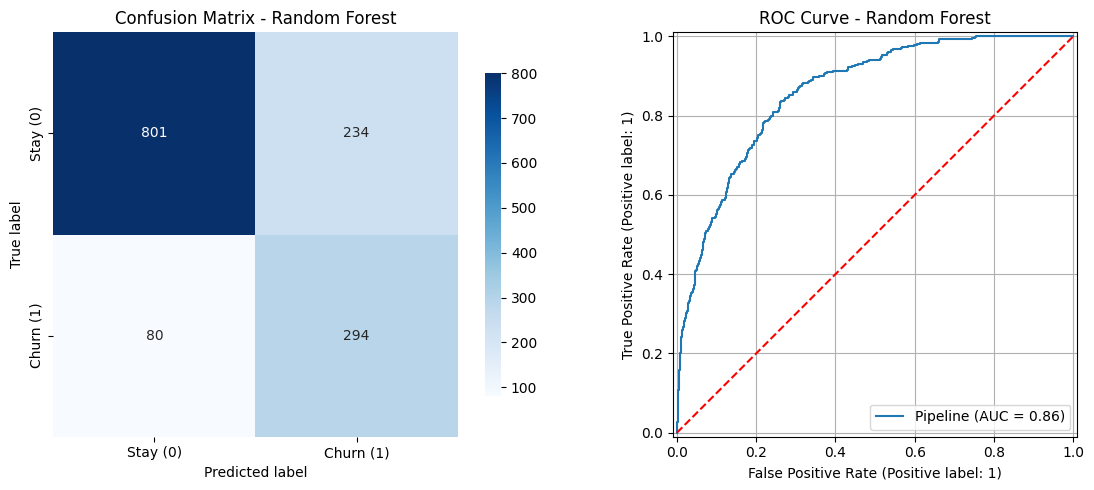

In [72]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True, cbar_kws={"shrink": .8},
            xticklabels=['Stay (0)', 'Churn (1)'], 
            yticklabels=['Stay (0)', 'Churn (1)'], ax=ax1)
ax1.set_xlabel('Predicted label')
ax1.set_ylabel('True label')
ax1.set_title('Confusion Matrix - Random Forest')

RocCurveDisplay.from_estimator(best_rf, X_test, y_test, ax=ax2)
ax2.plot([0, 1], [0, 1], color='red', linestyle='--')
ax2.set_title('ROC Curve - Random Forest')
ax2.set_aspect('equal')
ax2.grid(True)

plt.tight_layout()
plt.show()

Wykres pokazuje, że model poprawnie zidentyfikował 294 osoby faktycznie odchodzące oraz 801 lojalnych klientów. Błąd typu II wystąpił w 80 przypadkach, co oznacza, że algorytm skutecznie wyłapuje większość realnych rezygnacji, choć generuje przy tym zauważalną liczbę błędnych wskazań w grupie stabilnych klientów.

Wykres krzywej ROC z wynikiem AUC na poziomie 0.86 potwierdza wysoką skuteczność modelu w rozróżnianiu obu grup użytkowników. Wynik ten wskazuje, że Random Forest z dużym prawdopodobieństwem poprawnie różnicuje sygnały świadczące o chęci odejścia od zachowań typowych dla osób pozostających w firmie.